# Кейс №6

## Прогнозирование исходов заболевания циррозом печени с помощью ML

## Участники:

- Алёна Лозинская
- Валентина Кулакова
- Дмитрий Волобуев
- Артур Григорян
- Ильсия Коткова
- Матвей Радаев

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
import optuna
import shap

from catboost import CatBoostClassifier, Pool

In [2]:
plt.style.use("default")
sns.set_palette("Set2")

RANDOM_STATE = 42
TARGET_COL = "Status"
DROP_COL = ["id", "N_Days"]
N_TRIALS_CB = 50

# Этап I. Предобработка данных для ML

Загрузим данные, разделим наши признаки на числовые и категориальные, преобразуем таргет в бинарный, разделим на train и test.

In [3]:
df = pd.read_csv("../../data/train.csv").drop(columns=DROP_COL)

In [4]:
target_maps = {"C": 0, "D": 1}

binary_maps = {
    "Drug": {"Placebo": 0, "D-penicillamine": 1},
    "Sex": {"F": 0, "M": 1},
    "Ascites": {"N": 0, "Y": 1},
    "Hepatomegaly": {"N": 0, "Y": 1},
    "Spiders": {"N": 0, "Y": 1}
}

binary_features = list(binary_maps.keys())
multi_category_features = ["Edema", "Stage"]

numeric_features = ["Age", "Bilirubin", "Cholesterol", "Albumin", "Copper",
                    "Alk_Phos", "SGOT", "Tryglicerides", "Platelets", "Prothrombin"]

cat_features = binary_features + multi_category_features

def cast_cat_to_str(X: pd.DataFrame, cat_features):
    X = X.copy()
    for col in cat_features:
        if col in X.columns:
            X[col] = X[col].astype("string")
    return X

Исходный таргет с тремя категориями преобразуем в две и будем решать задачу бинарной классификации.

Класс CL означает, что пациент выжил благодаря трансплантации печени. А информации о том, кому была сделана или назначена трансплантация, в данных нет. Поэтому мы не можем корректно предсказать событие CL по исходным биохимическим показателям - оно зависит не только от тяжести болезни, но и от внешних факторов (решение врача, наличие органа, успешность операции). Среди представителей класса D также могли быть пациенты, которые перенесли трансплантацию печени, равно как и в классе C могут быть пациенты, которым предстоит операция, но мы об этом не знаем. Кроме того, CL очень малочисленный: всего 3.5% против 33.7% и 62.8% классов D и C соответственно. Поэтому его разумно исключить и решать задачу в виде бинарной классификации:

- Класс 0, умеренная стадия заболевания — C (пациент жив)
- Класс 1, тяжёлая стадия заболевания — D (летальный исход)

In [5]:
df = df[df[TARGET_COL] != 'CL'].reset_index(drop=True)

df[TARGET_COL] = df[TARGET_COL].map(target_maps)

df[TARGET_COL].value_counts(normalize=True)

Status
0    0.650721
1    0.349279
Name: proportion, dtype: float64

Разделим все данные на train и test. Подбор методов обработки признаков, настройку гиперпараметров и оценку качества будем проводить только на кросс-валидации на train. Test служит для финальной оценки качества лучшей модели.

In [6]:
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

X = cast_cat_to_str(X, cat_features)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

In [7]:
print("Распределение таргета на train:")
print(y_train.value_counts(normalize=True))

print("=="*25)

print("Распределение таргета на test:")
print(y_test.value_counts(normalize=True))

Распределение таргета на train:
Status
0    0.650721
1    0.349279
Name: proportion, dtype: float64
Распределение таргета на test:
Status
0    0.650721
1    0.349279
Name: proportion, dtype: float64


Числовые признаки оставим в исходном виде, поскольку ML-модели на основе деревьев не накладывают жёстких требований в виде масштабирования, коррекции асимметрии и борьбы с выбросами. Кодирование категориальных фичей также предоставим CatBoost - для этого нам всего лишь нужно передать список таких колонок.

Будем использовать StratifiedKFold, чтобы в каждом фолде была соблюдена пропорция классов. Установим 5 фолдов.

In [8]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Этап II. Обучение модели CatBoost

Напишем вспомогательные функции для создания общего пайплайна CatBoost и подбора гиперпараметров (включая методы сэмплирования для борьбы с дисбалансом классов) через optuna, реализуем ручную кросс-валидацию с механизмом early stopping. В функцию с подбором гиперпараметров можно передавать use_fe - значение True позволяет дополнить датасет кастомными признаками.

In [9]:
def add_fe_features(X: pd.DataFrame, fe_cols=None) -> pd.DataFrame:

    X = X.copy()
    if not fe_cols:
        fe_cols = ["Symptom_Score", "Bilirubin_Albumin_Ratio", "Coagulation_Index", "Enzyme_Pattern"]

    eps = 1e-6

    if "Symptom_Score" in fe_cols:
        mapping = {'N': 0, 'Y': 1, 'S': 1}
        X["Symptom_Score"] = (
            X["Ascites"].map(mapping)
            + X["Hepatomegaly"].map(mapping)
            + X["Spiders"].map(mapping)
            + X["Edema"].map(mapping)
        )

    if "Bilirubin_Albumin_Ratio" in fe_cols:
        X["Bilirubin_Albumin_Ratio"] = X["Bilirubin"] / (X["Albumin"] + eps)

    if "Coagulation_Index" in fe_cols:
        X["Coagulation_Index"] = X["Prothrombin"] / (X["Albumin"] + eps)

    if "Enzyme_Pattern" in fe_cols:
        X["Enzyme_Pattern"] = X["SGOT"] / (X["Alk_Phos"] + eps)

    return X


def make_cb_pipeline(trial):

    sampler_name = trial.suggest_categorical("sampler", ["passthrough", "under", "over"])
    if sampler_name == "passthrough":
        sampler = "passthrough"
    elif sampler_name == "under":
        sampler = RandomUnderSampler(random_state=RANDOM_STATE)
    else:
        sampler = RandomOverSampler(random_state=RANDOM_STATE)

    cb_params = {
        "loss_function": "Logloss",
        "eval_metric": "Logloss",
        "random_seed": RANDOM_STATE,
        "thread_count": -1,
        "allow_writing_files": False,
        "iterations": 5000,
        "learning_rate": trial.suggest_float("cb_learning_rate", 0.01, 0.3, log=True),
        "depth": trial.suggest_int("cb_depth", 3, 10),
        "l2_leaf_reg": trial.suggest_float("cb_l2_leaf_reg", 1e-2, 50.0, log=True),
        "random_strength": trial.suggest_float("cb_random_strength", 1e-2, 10.0, log=True),
        "bagging_temperature": trial.suggest_float("cb_bagging_temperature", 0.0, 1.0),
        "min_data_in_leaf": trial.suggest_int("cb_min_data_in_leaf", 1, 50),
        "subsample": trial.suggest_float("cb_subsample", 0.5, 1.0),
    }

    class_weight_mode = trial.suggest_categorical("cb_class_weights", ["none", "balanced"])
    if class_weight_mode == "balanced":
        cb_params["auto_class_weights"] = "Balanced"

    cb = CatBoostClassifier(**cb_params)

    pipe = Pipeline([("cb", cb)])

    return pipe, sampler_name, sampler


def create_best_pipeline_cb(study):

    best_params = study.best_trial.params

    sampler_name = best_params.get("sampler", "passthrough")
    if sampler_name == "passthrough":
        sampler = "passthrough"
    elif sampler_name == "under":
        sampler = RandomUnderSampler(random_state=RANDOM_STATE)
    else:
        sampler = RandomOverSampler(random_state=RANDOM_STATE)

    cb_params = {
        "loss_function": "Logloss",
        "eval_metric": "Logloss",
        "random_seed": RANDOM_STATE,
        "thread_count": -1,
        "allow_writing_files": False,
        "iterations": 5000,
        "learning_rate": best_params["cb_learning_rate"],
        "depth": best_params["cb_depth"],
        "l2_leaf_reg": best_params["cb_l2_leaf_reg"],
        "random_strength": best_params["cb_random_strength"],
        "bagging_temperature": best_params["cb_bagging_temperature"],
        "min_data_in_leaf": best_params["cb_min_data_in_leaf"],
        "subsample": best_params["cb_subsample"],
    }

    if best_params.get("cb_class_weights") == "balanced":
        cb_params["auto_class_weights"] = "Balanced"

    cb = CatBoostClassifier(**cb_params)

    pipe = Pipeline([("cb", cb)])

    return pipe, sampler_name, sampler


def apply_sampler(sampler, X, y):
    if sampler == "passthrough":
        return X, y
    X_res, y_res = sampler.fit_resample(X, y)
    if not isinstance(X_res, pd.DataFrame):
        X_res = pd.DataFrame(X_res, columns=X.columns)
    return X_res, y_res


def optuna_cv_search_cb(make_pipeline_fn, X, y, cv, n_trials=50, scoring="recall",
                        early_stopping_rounds=10, random_state=RANDOM_STATE,
                        cat_features_list=None, use_fe=False, fe_cols=None):
    
    if use_fe:
        X = add_fe_features(X, fe_cols=fe_cols)

    def score_fold(y_true, y_pred):
        if scoring == "recall":
            return recall_score(y_true, y_pred)
        elif scoring == "precision":
            return precision_score(y_true, y_pred)
        elif scoring == "f1":
            return f1_score(y_true, y_pred)
        else:
            raise ValueError(f"Unsupported scoring: {scoring}")

    def objective(trial):

        pipe, sampler_name, sampler = make_pipeline_fn(trial)
        fold_scores = []

        for train_idx, valid_idx in cv.split(X, y):

            X_tr, X_val = X.iloc[train_idx], X.iloc[valid_idx]
            y_tr, y_val = y.iloc[train_idx], y.iloc[valid_idx]

            X_tr_rs, y_tr_rs = apply_sampler(sampler, X_tr, y_tr)

            pipe_fold = Pipeline(pipe.steps)
            pipe_fold.fit(
                X_tr_rs, y_tr_rs,
                cb__cat_features=cat_features_list,
                cb__eval_set=(X_val, y_val),
                cb__early_stopping_rounds=early_stopping_rounds,
                cb__use_best_model=True,
                cb__verbose=False
            )

            y_pred_val = pipe_fold.predict(X_val)
            y_pred_val = np.array(y_pred_val).astype(int).ravel()
            fold_scores.append(score_fold(y_val, y_pred_val))

        return float(np.mean(fold_scores))

    sampler = optuna.samplers.TPESampler(seed=random_state)
    study = optuna.create_study(direction="maximize", sampler=sampler)
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return study


def cv_predict_proba_cb(pipe, sampler, X, y, cv, early_stopping_rounds=10,
                        cat_features_list=None, use_fe=False, fe_cols=None):

    if use_fe:
        X = add_fe_features(X, fe_cols=fe_cols)    
    
    oof = np.zeros(len(X), dtype=float)

    for train_idx, valid_idx in cv.split(X, y):

        X_tr, X_val = X.iloc[train_idx], X.iloc[valid_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[valid_idx]

        X_tr_rs, y_tr_rs = apply_sampler(sampler, X_tr, y_tr)

        pipe_fold = Pipeline(pipe.steps)
        pipe_fold.fit(
            X_tr_rs, y_tr_rs,
            cb__cat_features=cat_features_list,
            cb__eval_set=(X_val, y_val),
            cb__early_stopping_rounds=early_stopping_rounds,
            cb__use_best_model=True,
            cb__verbose=False
        )

        oof[valid_idx] = pipe_fold.predict_proba(X_val)[:, 1]

    return oof

Напишем вспомогательные функции для визуализаций

In [10]:
def plot_feature_importances_cb(
    pipeline,
    X,
    title="Важность признаков (CatBoost)",
    top_n=None,
    cat_features_list=None,
    use_fe=False,
    fe_cols=None,
):

    X_tr = add_fe_features(X, fe_cols=fe_cols) if use_fe else X.copy()

    if len(pipeline.steps) > 1:
        fe = pipeline[:-1]
        X_tr = fe.transform(X_tr)

    if not isinstance(X_tr, pd.DataFrame):
        raise ValueError("X_tr is not a pd df so feature names are unknown!")

    model = pipeline.named_steps["cb"]
    importances = model.get_feature_importance(type="FeatureImportance")

    df_imp = (
        pd.DataFrame({"feature": X_tr.columns, "importance": importances})
        .sort_values("importance", ascending=False)
    )

    if top_n is not None:
        df_imp = df_imp.head(top_n)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_imp, x="importance", y="feature")
    plt.title(title)
    plt.tight_layout()
    plt.show()


# кривые precision, recall, F1 в зависимости от порога (используем OOF proba с early stopping)
def plot_threshold_curves_cb(
    pipeline,
    sampler,
    X,
    y,
    cv,
    title="Зависимость метрик от порога (CatBoost)",
    cat_features_list=None,
    use_fe=False,
    fe_cols=None,
    early_stopping_rounds=10,
):

    y_proba = cv_predict_proba_cb(
        pipeline,
        sampler,
        X,
        y,
        cv=cv,
        early_stopping_rounds=early_stopping_rounds,
        cat_features_list=cat_features_list,
        use_fe=use_fe,
        fe_cols=fe_cols,
    )

    thresholds = np.arange(0.1, 0.91, 0.05)
    recalls, precisions, f1s = [], [], []

    for thr in thresholds:
        y_thr = (y_proba >= thr).astype(int)
        recalls.append(recall_score(y, y_thr))
        precisions.append(precision_score(y, y_thr))
        f1s.append(f1_score(y, y_thr))

    plt.figure(figsize=(8, 4))
    plt.plot(thresholds, recalls, label="Recall")
    plt.plot(thresholds, precisions, label="Precision")
    plt.plot(thresholds, f1s, label="F1")
    plt.xlabel("Порог вероятности")
    plt.ylabel("Метрика")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.title(title)
    plt.tight_layout()
    plt.show()


# матрица ошибок
def plot_confusion_matrix_simple(y_true, y_pred, title="Матрица ошибок"):
    
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Pred")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()


# визуализация важности признаков по версии SHAP (CatBoost)
def plot_shap_cb(
    pipeline,
    X,
    cat_features_list=None,
    use_fe=False,
    fe_cols=None,
):

    X_tr = add_fe_features(X, fe_cols=fe_cols) if use_fe else X.copy()

    if len(pipeline.steps) > 1:
        fe = pipeline[:-1]
        X_tr = fe.transform(X_tr)

    if not isinstance(X_tr, pd.DataFrame):
        raise ValueError("X_tr is not a pd df so feature names are unknown!")

    model = pipeline.named_steps["cb"]

    pool = Pool(X_tr, cat_features=cat_features_list)
    shap_vals = model.get_feature_importance(pool, type="ShapValues")

    shap_values = shap_vals[:, :-1] 
    shap.initjs()
    shap.summary_plot(shap_values, X_tr)
    plt.tight_layout()
    plt.show()

## 1. CatBoost

Подбираем гиперпараметры на исходном наборе признаков (use_fe=False), передаём кол-во испытаний и список категориальных фичей для Catboost.

In [ ]:
study_cb = optuna_cv_search_cb(lambda t: make_cb_pipeline(t),
                               X_train,
                               y_train,
                               cv=skf,
                               n_trials=N_TRIALS_CB,
                               cat_features_list=cat_features,
                               use_fe=False
                              )

In [12]:
print("CatBoost best pipeline:")
print(f"Best params: {study_cb.best_trial.params}")
print(f"Best recall: {study_cb.best_value:.4f}")

CatBoost best pipeline:
Best params: {'sampler': 'under', 'cb_learning_rate': 0.13123395014050226, 'cb_depth': 6, 'cb_l2_leaf_reg': 46.375677778122295, 'cb_random_strength': 0.024303242348848293, 'cb_bagging_temperature': 0.224796707431773, 'cb_min_data_in_leaf': 3, 'cb_subsample': 0.8277274325652207, 'cb_class_weights': 'none'}
Best recall: 0.8213


In [13]:
best_pipeline, best_sampler_name, best_sampler = create_best_pipeline_cb(study_cb)

y_proba_oof = cv_predict_proba_cb(best_pipeline,
                                  best_sampler,
                                  X_train,
                                  y_train,
                                  cv=skf,
                                  cat_features_list=cat_features,
                                  use_fe=False)

y_pred = (y_proba_oof >= 0.5).astype(int)

print("CatBoost best estimator:")
print(classification_report(y_train, y_pred))

CatBoost best estimator:
              precision    recall  f1-score   support

           0       0.90      0.84      0.87      3972
           1       0.74      0.82      0.78      2132

    accuracy                           0.83      6104
   macro avg       0.82      0.83      0.82      6104
weighted avg       0.84      0.83      0.84      6104



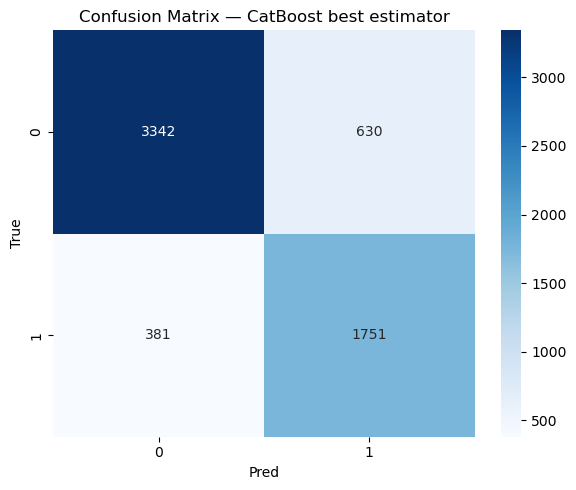

In [14]:
plot_confusion_matrix_simple(y_train, y_pred, title="Confusion Matrix — CatBoost best estimator")

Наилучшее качество по ключевой метрике (recall) демонстрирует модель CatBoost, использующая RandomUnderSampler как метод борьбы с дисбалансом классов, с умеренной глубиной деревьев и сильной регуляризацией:

- recall - 0.82
- precision - 0.74

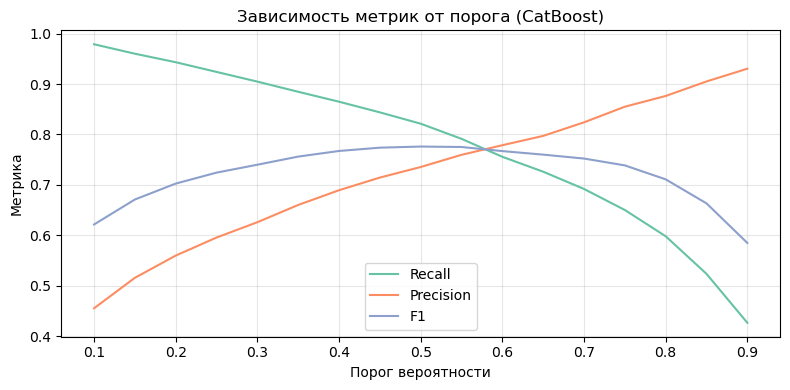

In [15]:
plot_threshold_curves_cb(best_pipeline,
                         best_sampler,
                         X_train,
                         y_train,
                         cv=skf,
                         title="Зависимость метрик от порога (CatBoost)",
                         cat_features_list=cat_features,
                         use_fe=False)

При этом видим, что с помощью изменения порога можно поднять recall, несколько потеряв в precision. Выберем порог 0.3, чтобы достигнуть отметки recall 0.9, при этом не "уронить" precision ниже 0.6. 

In [16]:
THRESHOLD = 0.3

y_proba = cv_predict_proba_cb(best_pipeline,
                              best_sampler,
                              X_train,
                              y_train,
                              cv=skf,
                              cat_features_list=cat_features,
                              use_fe=False)

y_pred_thr = (y_proba >= THRESHOLD).astype(int)

print(f"Отчёт по классам (порог {THRESHOLD}):")
print(classification_report(y_train, y_pred_thr))

Отчёт по классам (порог 0.3):
              precision    recall  f1-score   support

           0       0.93      0.71      0.81      3972
           1       0.63      0.90      0.74      2132

    accuracy                           0.78      6104
   macro avg       0.78      0.81      0.77      6104
weighted avg       0.83      0.78      0.78      6104



## 2. CatBoost + Feature Engineering

Попробуем добавить кастомные фичи в признаковое пространство и заново подобрать гиперпараметры. Активируем флаг use_fe, параметр fe_cols можно не передавать - по умолчанию будут сгенерированы все 4 новых признака.

In [ ]:
study_cb_fe = optuna_cv_search_cb(lambda t: make_cb_pipeline(t),
                                  X_train,
                                  y_train,
                                  cv=skf,
                                  n_trials=N_TRIALS_CB,
                                  cat_features_list=cat_features,
                                  use_fe=True
                                 )

In [18]:
print("Best pipeline (CatBoost + FE):")
print(f"Best params: {study_cb_fe.best_trial.params}")
print(f"Best recall: {study_cb_fe.best_value:.4f}")

Best pipeline (CatBoost + FE):
Best params: {'sampler': 'under', 'cb_learning_rate': 0.1907232272999395, 'cb_depth': 8, 'cb_l2_leaf_reg': 45.85500709482166, 'cb_random_strength': 8.323144279644582, 'cb_bagging_temperature': 0.6721975950733878, 'cb_min_data_in_leaf': 20, 'cb_subsample': 0.5074900241609404, 'cb_class_weights': 'balanced'}
Best recall: 0.8194


In [19]:
best_pipeline_fe, best_sampler_fe_name, best_sampler_fe = create_best_pipeline_cb(study_cb_fe)

y_proba_fe_oof = cv_predict_proba_cb(best_pipeline_fe,
                                     best_sampler_fe,
                                     X_train,
                                     y_train,
                                     cv=skf,
                                     cat_features_list=cat_features,
                                     use_fe=True)

y_pred_fe = (y_proba_fe_oof >= 0.5).astype(int)

print("CatBoost + FE best estimator:")
print(classification_report(y_train, y_pred_fe))

CatBoost + FE best estimator:
              precision    recall  f1-score   support

           0       0.90      0.84      0.87      3972
           1       0.73      0.82      0.77      2132

    accuracy                           0.83      6104
   macro avg       0.81      0.83      0.82      6104
weighted avg       0.84      0.83      0.83      6104



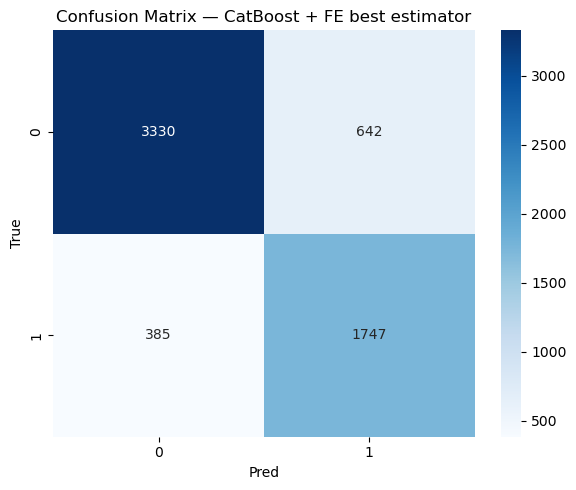

In [20]:
plot_confusion_matrix_simple(y_train, y_pred_fe,
                             title="Confusion Matrix — CatBoost + FE best estimator")

Видим незначительную потерю в качестве по сравнению с исходным набором признаков: precision снизился на единицу, отмечаются малые потери в recall.

Оценим важность признаков по версиям CatBoost и SHAP. Исключение из датасета избыточных признаков может потенциально улучшить качество модели.

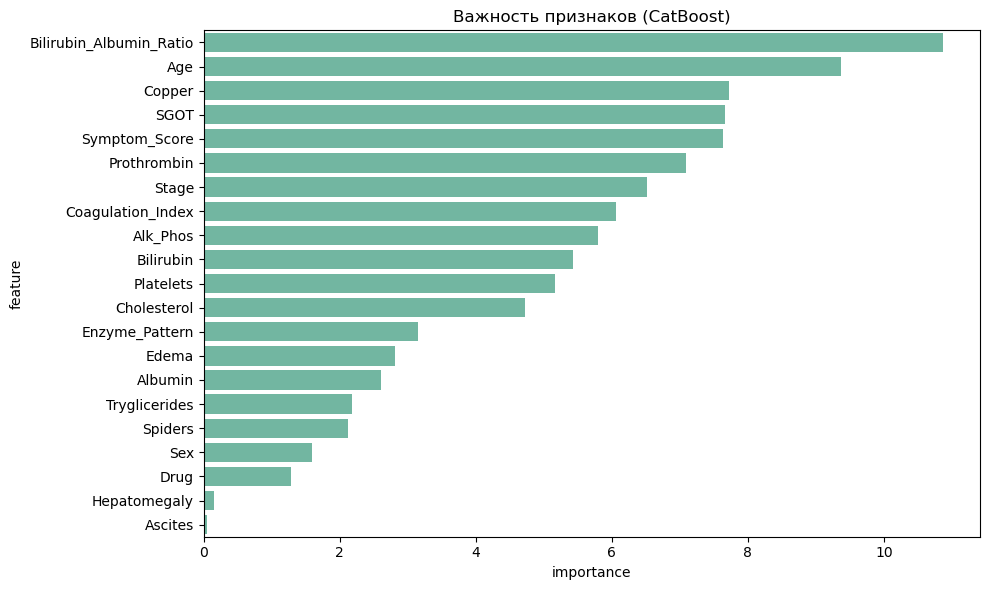

In [21]:
# обучим модель на полном train (с early stopping на небольшом holdout) и посмотрим важность признаков
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=RANDOM_STATE
)

X_tr_fe = add_fe_features(X_tr)
X_val_fe = add_fe_features(X_val)

best_pipeline_fe.fit(
    X_tr_fe, y_tr,
    cb__cat_features=cat_features,
    cb__eval_set=(X_val_fe, y_val),
    cb__early_stopping_rounds=10,
    cb__use_best_model=True,
    cb__verbose=False
)

plot_feature_importances_cb(best_pipeline_fe,
                            X_train,
                            title="Важность признаков (CatBoost)",
                            cat_features_list=cat_features,
                            use_fe=True)

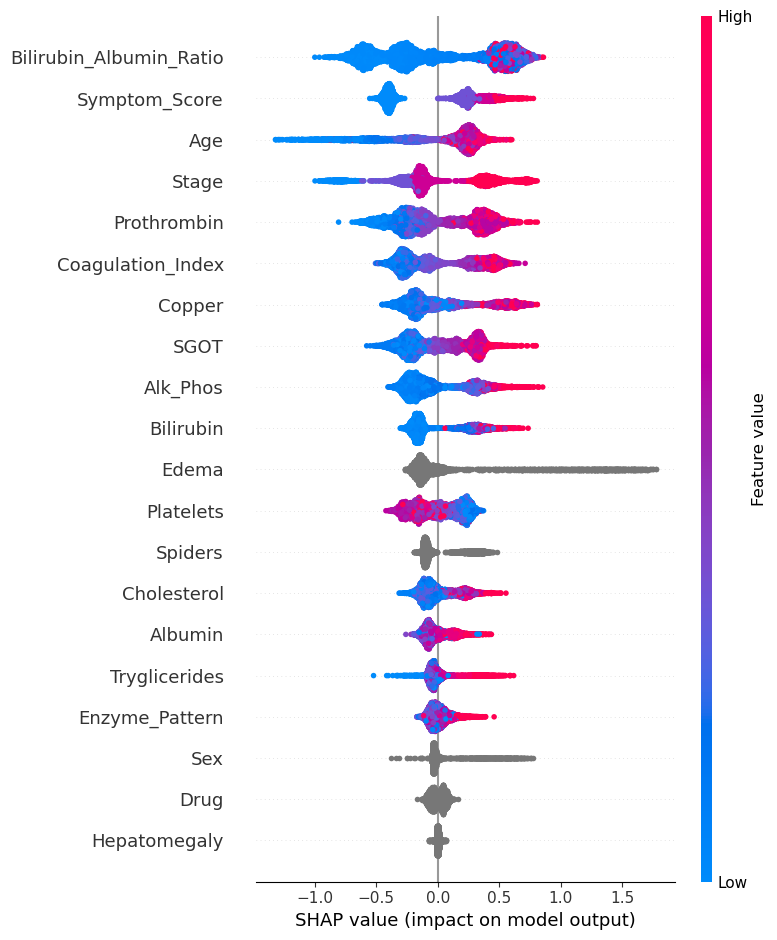

<Figure size 640x480 with 0 Axes>

In [22]:
plot_shap_cb(best_pipeline_fe,
             X_train,
             use_fe=True,
             cat_features_list=cat_features)

Согласно встроенной в CatBoost оценке важности признаков, большинство бинарных категориальных признаков вносят низкий вклад в предсказания модели. Такие признаки, как Ascites и Hepatomegaly, демонстрируют практически нулевую важность и могут рассматриваться как кандидаты на исключение из признакового пространства. Данный вывод также подтверждается анализом SHAP, согласно которого в список низкозначимых фичей можно также добавить Sex и Drug.

Признак Stage также имеет высокую важность согласно обеим оценкам, поэтому его рекомендуется оставить.

Три из четырёх кастомных признаков демонстрируют высокий вклад в качество модели. При этом признак Enzyme_Pattern оказывает сравнительно меньшее влияние: в анализе SHAP его значимость ниже, чем в нативной оценке важности признаков CatBoost.

Следует также учитывать, что при исключении бинарных категориальных признаков становится невозможным формирование признака Symptom_Score, который, согласно обеим метрикам, обладает существенной предсказательной значимостью.

Попробуем исключить из признакового пространства следующие фичи: 'Ascites', 'Drug', 'Sex', 'Spiders', 'Hepatomegaly'.

In [25]:
fe_cols_new = ['Bilirubin_Albumin_Ratio', 'Coagulation_Index', 'Enzyme_Pattern']

X_train_new = X_train.drop(['Ascites', 'Drug', 'Sex', 'Spiders', 'Hepatomegaly'], axis=1).copy()

cat_features_new = [c for c in cat_features if c in X_train_new.columns]

In [ ]:
study_cb_fe_new = optuna_cv_search_cb(lambda t: make_cb_pipeline(t),
                                      X_train_new,
                                      y_train,
                                      cv=skf,
                                      n_trials=N_TRIALS_CB,
                                      cat_features_list=cat_features_new,
                                      use_fe=True,
                                      fe_cols=fe_cols_new
                                     )

In [27]:
print("Best pipeline (CatBoost + FE, some features removed):")
print(f"Best params: {study_cb_fe_new.best_trial.params}")
print(f"Best recall: {study_cb_fe_new.best_value:.4f}")

Best pipeline (CatBoost + FE, some features removed):
Best params: {'sampler': 'under', 'cb_learning_rate': 0.04043542923059311, 'cb_depth': 5, 'cb_l2_leaf_reg': 0.08406502411628909, 'cb_random_strength': 0.4788620221684964, 'cb_bagging_temperature': 0.1528255073895809, 'cb_min_data_in_leaf': 26, 'cb_subsample': 0.9110726133763113, 'cb_class_weights': 'balanced'}
Best recall: 0.8114


In [28]:
best_pipeline_fe_new, best_sampler_fe_new_name, best_sampler_fe_new = create_best_pipeline_cb(study_cb_fe_new)

y_proba_fe_new_oof = cv_predict_proba_cb(best_pipeline_fe_new,
                                         best_sampler_fe_new,
                                         X_train_new,
                                         y_train,
                                         cv=skf,
                                         cat_features_list=cat_features_new,
                                         use_fe=True,
                                         fe_cols=fe_cols_new)

y_pred_fe_new = (y_proba_fe_new_oof >= 0.5).astype(int)

print("CatBoost + FE best estimator (some features removed):")
print(classification_report(y_train, y_pred_fe_new))

CatBoost + FE best estimator (some features removed):
              precision    recall  f1-score   support

           0       0.89      0.84      0.87      3972
           1       0.73      0.81      0.77      2132

    accuracy                           0.83      6104
   macro avg       0.81      0.83      0.82      6104
weighted avg       0.84      0.83      0.83      6104



Видим, что удаление части признаков не привело к улучшению метрик: мы потеряли и в recall, и в precision. В качестве лучшей модели будем использовать модель с исходным набором признаков и выбранным порогом.

# Этап III. Проверка на тесте

Обучим лучший пайплайн на полном train и оценим важность признаков по версиям CatBoost и SHAP, чтобы сделать модель интерпретируемой.

In [36]:
final_pipeline, final_sampler_name, final_sampler = create_best_pipeline_cb(study_cb)

Для финального обучения используем early stopping на внутреннем holdout (всего 10% данных, чтобы оставить как можно больше обектов для обучения)

In [37]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.1, stratify=y_train, random_state=RANDOM_STATE
)

if final_sampler != "passthrough":
    X_tr_rs, y_tr_rs = apply_sampler(final_sampler, X_tr, y_tr)
else:
    X_tr_rs, y_tr_rs = X_tr, y_tr

final_pipeline.fit(
    X_tr_rs, y_tr_rs,
    cb__cat_features=cat_features,
    cb__eval_set=(X_val, y_val),
    cb__early_stopping_rounds=10,
    cb__use_best_model=True,
    cb__verbose=False
)

Pipeline(steps=[('cb',
                 <catboost.core.CatBoostClassifier object at 0x000002F3BE21DAC0>)])

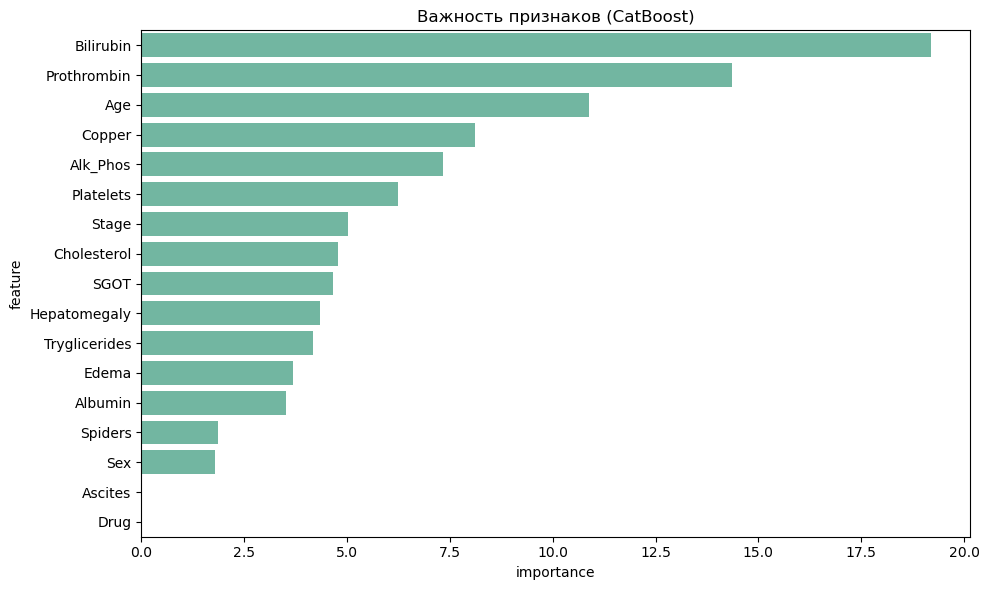

In [38]:
plot_feature_importances_cb(final_pipeline, X_train, title="Важность признаков (CatBoost)",
                            use_fe=False, cat_features_list=cat_features)

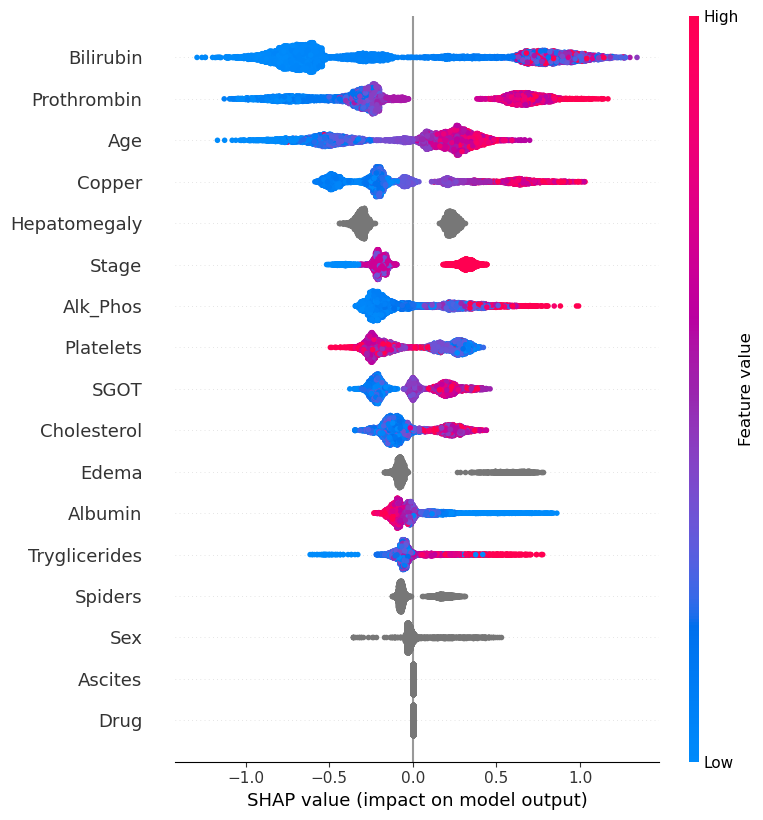

<Figure size 640x480 with 0 Axes>

In [39]:
plot_shap_cb(final_pipeline, X_train, use_fe=False, cat_features_list=cat_features)

По SHAP-графику видно, что наиболее важными признаками для модели являются биохимические показатели: Bilirubin, Prothrombin и Copper. Точки красного цвета (высокие значения признака) у Bilirubin, Prothrombin и Copper в основном находятся справа, то есть большие значения этих показателей обычно увеличивают вероятность неблагоприятного исхода (класс 1). Для Platelets и Albumin картина обратная: низкие значения чаще связаны с неблагоприятным течением болезни. Среди категориальных признаков наибольший вклад вносят Stage и Hepatomegaly. Остальные признаки (например, Ascites и Drug) влияют заметно слабее - их точки в основном сгруппированы ближе к нулю.

In [40]:
y_proba_test = final_pipeline.predict_proba(X_test)[:, 1]
y_pred_test = (y_proba_test >= THRESHOLD).astype(int)

In [41]:
print(f"Test CatBoost best estimator (threshold={THRESHOLD}):")
print(classification_report(y_test, y_pred_test))

Test CatBoost best estimator (threshold=0.3):
              precision    recall  f1-score   support

           0       0.94      0.69      0.79       993
           1       0.61      0.91      0.73       533

    accuracy                           0.77      1526
   macro avg       0.77      0.80      0.76      1526
weighted avg       0.82      0.77      0.77      1526



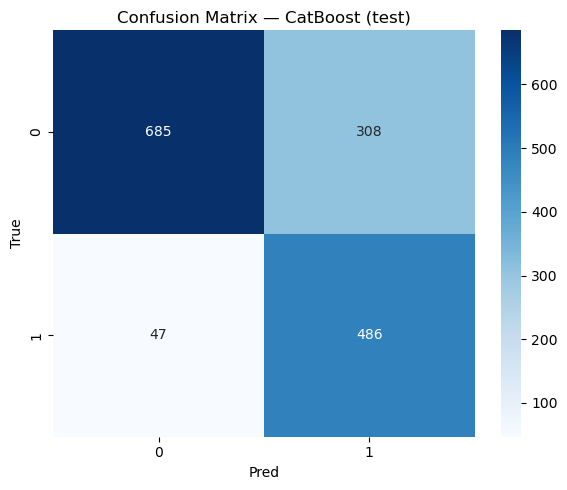

In [42]:
plot_confusion_matrix_simple(y_test, y_pred_test,
                             title="Confusion Matrix — CatBoost (test)")

# Выводы

**Моделирование:**

Проведена оценка моделей CatBoost, использующих разные методы для борьбы с дисбалансом классов. Лучший результат по метрике recall для класса 1 показала модель с даунсэмплингом. Кроме того, были проведены эксперименты по изменению порога принятия решений и генерации дополнительных признаков. Добавление новых признаков не улучшило ключевую метрику. Оптимальным значением порога вероятности является отметка в 0.3. Кроме того, проведена оценка важности признаков на основе встроенного feature importance и SHAP. Наиболее важными признаками для модели являются биохимические показатели: Bilirubin, Prothrombin и Copper.  

**Результаты:**

На тесте выбранная модель демонстрирует recall класса 1 = 0.91 и precision класса 1 = 0.61. На данный момент это лучший результат в сравнении со случайным лесом (0.91 и 0.6 соответственно), логистической регрессией (0.89 и 0.58 соответственно) и деревом решений (0.88 и 0.54 соответственно).